# Improving Forecaster Performance via Automated Calibration Adjustment

## Main Takeaways

- **Forecaster performance can be improved using statistical methods**: By applying a calibration adjustment trained on a particular forecaster, a statistically significant improvement can be made to their Brier score.
- **Improvement is modest**: Brier scores decreased at max by about 0.02, although for some forecasters, this is not insignificant given many were in the 0.15 to 0.20 range.
- **These methodologies are open source and computationally cheap**: The code to apply these adjustments, for instance, to a bot, is available at <https://github.com/Metaculus/forecasting-tools/tree/feat/calibration/forecasting_tools/calibration_adjustments>.
- **Further work needs to be done to apply calibration adjustments to continuous domained questions**: The Platt scaling method should be relatively easily adaptable.
- **The methodologies in this article are not exhaustive and may be improved**: More methodologies may also be tried, such as using a simple neural network or isotonic regression.

## Introduction

A perfectly calibrated forecaster assigns probability $p$ to events that resolve positively $p\%$ of the time. In practice, most forecasting agents — human or automated — deviate from this ideal. For example, here is the calibration curve of a top professional forecaster:

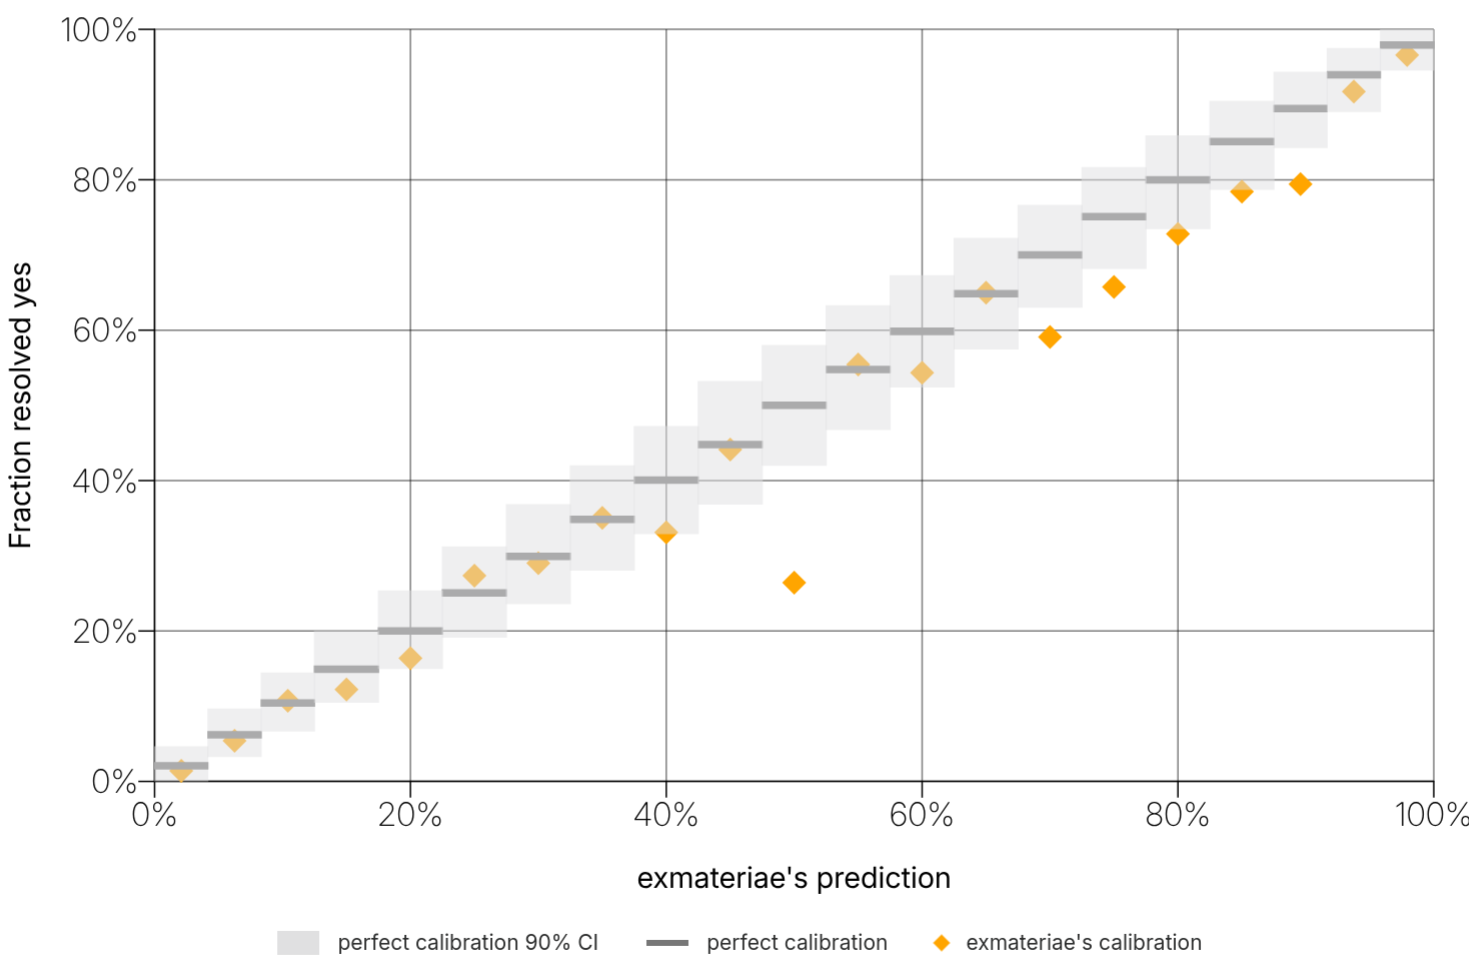

And here is the calibration curve of one of the top performing bots:

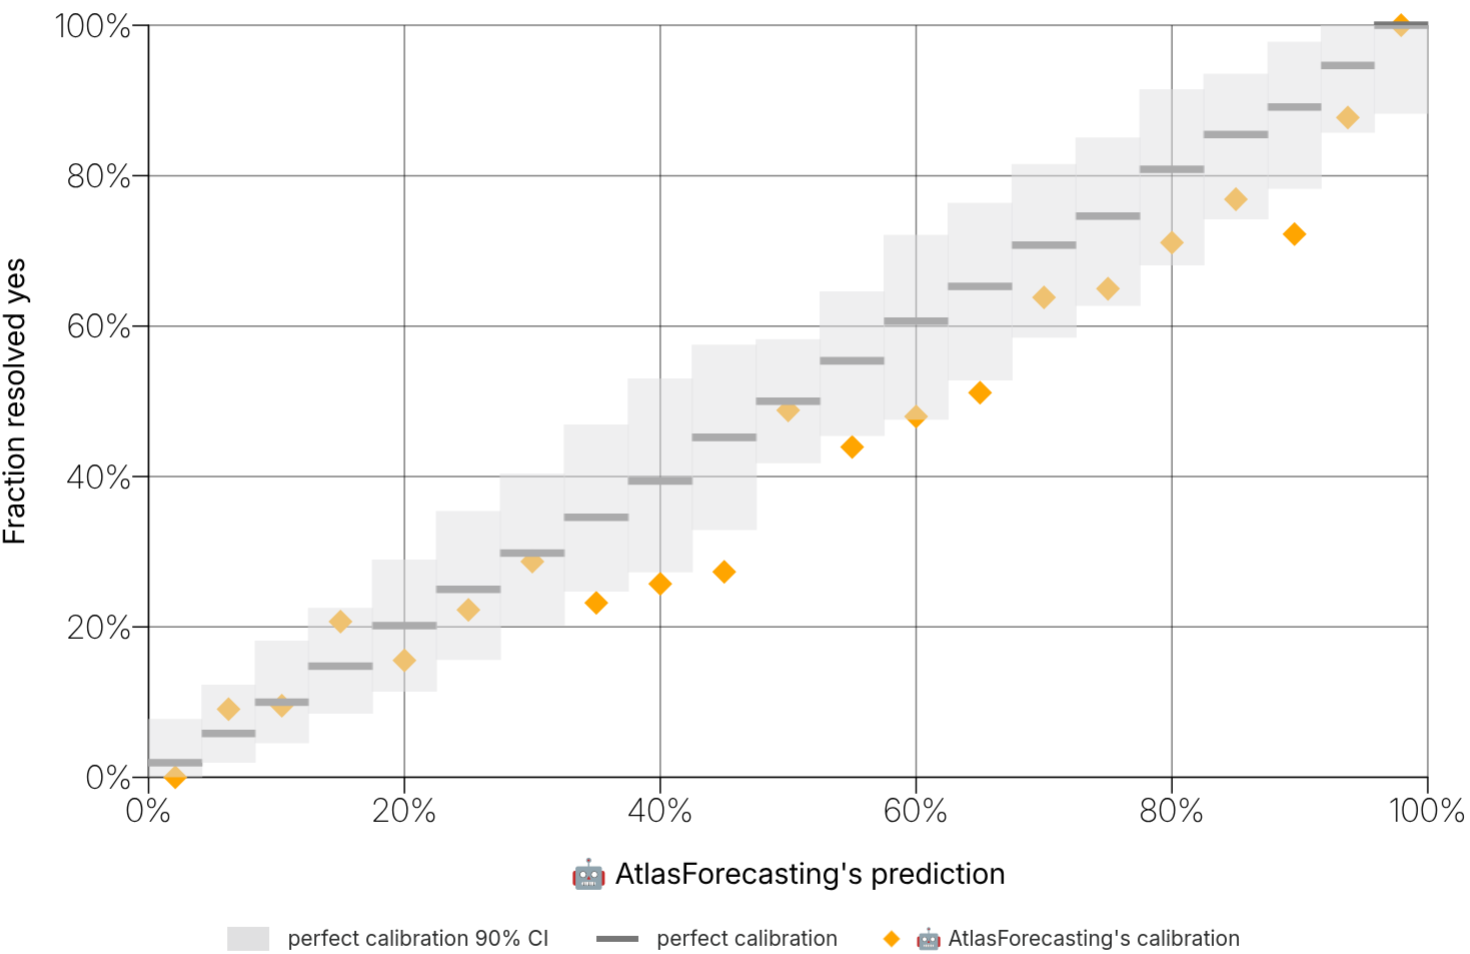

With both the bot and professional, there are regions where their calibration (seen by the yellow dots) strays from the perfect calibration line. From this, a question can be derived: if a forecaster is regularly under- or over-confident with forecasts submitted at probability $p$, could this be corrected for? This question is even more pertinent with bots than professionals, as humans will adjust their thinking subtly over time, but bots can be frozen in place.

This article benchmarks several strategies to explore the feasibility and benefit of applying simple statistical adjustments to a forecaster's inputs to improve calibration.

## Calibration Adjustment Strategies

There are multiple feasible approaches to this problem, but they all follow the same general procedure:

1. Create a train/test partitioning of a forecaster's historical forecasts. Forecasts are sorted chronologically, and the earliest 70% are used for training while the most recent 30% form the held-out test set.
2. Train a model based on the historical forecasts of a given forecaster in the training partition.
3. Use the trained model to adjust the predictions in the test partition.
4. For each forecaster, calculate the Brier score of the pre-adjustment and post-adjustment test partition.
5. Test whether there is a statistically significant improvement in Brier scores after adjustment.

### Strategy 1: Uniform Shift

This is the simplest approach. We compute the mean residual across all training observations and add this to every future prediction. This corrects only global mean bias: if a forecaster systematically underestimates by 3 percentage points, the shift is +0.03. It cannot fix local under- or over-confidence.

For multiple-choice questions, this approach has a structural weakness: after adding a constant offset $\delta$ to each raw probability and renormalizing, the adjusted predictions $p_{A,n} \propto p_n + \delta$ converge toward a uniform distribution as $\delta \to \infty$, thereby reducing the information content of the original forecast. We therefore expect this strategy to perform poorly on multiple-choice questions.

### Strategy 2: Step Shift

Building on the uniform shift, the next natural step is to partition the domain into $N$ equal-width subdomains. This is, after all, how Metaculus plots its calibration curves. For each subdomain $1 \le n \le N$, the same procedure as the uniform shift is applied, but trained only on forecasts made in the range $[\frac{n-1}{N}, \frac{n}{N}]$.

The number of steps $N$ is selected automatically by further splitting the training data into an internal train/validation set and evaluating candidate values of $N \in [1, 30]$, selecting the value that yields the lowest Brier score on the internal validation set. Note that $N = 1$ is equivalent to a uniform shift.

### Strategy 3: K-Means Shift

Rather than partitioning into $N$ equal-width subdomains, we instead define $K$ cluster centres, and assign each forecast to its nearest centre. This is trained using K-means clustering, and can be useful for capturing under- or over-confidence in regions with a high density of predictions (for example, near the extremes of $\approx 0$ and $\approx 1$).

The value of $K$ is selected via the same internal validation procedure as $N$ in the step shift adjustment. Note that $K = 1$ is equivalent to a uniform shift.

### Strategy 4: Decision Tree

This model partitions the $[0, 1]$ probability axis into adaptive-width bins (up to 32 bins, each containing at least 30 training observations). For each bin, it stores the empirical resolution rate. At adjustment time, a raw prediction is routed to its bin and replaced by that bin's empirical resolution rate. This is the most flexible approach — it can correct arbitrary bin-level miscalibration — but it is also susceptible to overfitting, as bin-level resolution rates estimated from finite samples may not generalize to held-out data.

### Strategy 5: Logistic Recalibration (Platt Scaling)

Fits an affine transformation in log-odds space: $adjusted = \sigma\!\left(\frac{\operatorname{logit}(p) - \mathrm{bias}}{\mathrm{confidence}}\right)$. This is equivalent to fitting a logistic regression of outcomes on the log-odds of predictions. The adjustment is smooth and monotonic, and its two parameters have direct interpretations in terms of the two most common forms of miscalibration:
- **bias** corrects systematic under- or over-estimation.
- **confidence** corrects under- or over-confidence (i.e., whether predictions are too extreme or too conservative).

This approach can fail in two cases, both of which result in the affected forecaster being excluded from evaluation for this strategy: (1) the training data contains only one resolution class (all "yes" or all "no"), since logistic regression cannot be fit in that case; and (2) the fitted slope is non-positive, indicating that the forecaster's raw predictions are anti-correlated with outcomes, which would produce a non-monotonic recalibration.

In [1]:
import json
import logging
import warnings
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bot_forecasts = pd.read_csv("./bot_forecasts_q1.csv")
bot_forecasts = pd.concat([pd.read_csv("./bot_forecasts_q2.csv"), bot_forecasts])


logging.disable(logging.CRITICAL)
warnings.filterwarnings("ignore")

TRAIN_FRAC = 0.70
MIN_FORECASTS = 500
N_BOOTSTRAP = 1000
RANDOM_STATE = 0

rng_global = np.random.default_rng(RANDOM_STATE)

## Measuring Forecast Quality: the Brier Score

The **Brier score** is a metric used in forecasting that is equivalent to the mean squared error (MSE) of the forecasts made. This analysis is restricted to binary and multiple-choice questions. A multiple-choice question with $N$ options can be thought of as $N$ binary questions where $\sum_{n=1}^{N} p_n = 1$.

Throughout this notebook, we report $\Delta = \operatorname{Brier}(\text{raw}) - \operatorname{Brier}(\text{adjusted})$. **Positive deltas indicate that the adjuster improved the forecast.**

**A note on comparing binary and multiple-choice Brier scores.** The raw multiple-choice Brier definition $\sum_i (p_i - y_i)^2$ sums squared errors over $K$ options, so its magnitude scales with $K$ and is not on the same $[0, 1]$ scale as the binary Brier score. To make the two more directly comparable, we report the **per-option mean squared error** for multiple-choice questions, i.e. we divide the standard MC Brier by $K$. Even with this normalization, binary and MC Brier are still not perfectly equivalent metrics &mdash; the per-question variance and baseline rates differ between question types &mdash; so cross-type comparisons of absolute Brier values should be interpreted with care. Within a single question type, deltas (raw vs. adjusted) and the associated $p$-values remain the primary quantities of interest.

In [2]:
def brier_binary(p: float, resolution: str) -> float:
    """Brier score for a binary forecast given 'yes'/'no' resolution."""
    outcome = 1.0 if resolution == "yes" else 0.0
    return (float(p) - outcome) ** 2


def brier_mc(p_vec, options, resolution_label) -> float:
    """Per-option mean Brier score for a multiple-choice forecast.

    Computes sum_i (p_i - 1[option_i == resolution])^2 / K, where K is the
    number of options. Dividing by K places the MC Brier score on roughly the
    same [0, 1] scale as a binary Brier score, so the two are more directly
    comparable. Without this normalization, MC Brier scales with K and is
    not comparable across question types.
    """
    p = np.asarray(p_vec, dtype=float)
    y = np.asarray([1.0 if opt == resolution_label else 0.0 for opt in options])
    k = len(options)
    if k == 0:
        return float("nan")
    return float(np.sum((p - y) ** 2) / k)

def _df_brier(test_df) -> float | None:
    """Brier score across all usable rows in a test DataFrame."""
    if test_df is None or (isinstance(test_df, float) and np.isnan(test_df)):
        return None
    scores = []
    for _, row in test_df.iterrows():
        if row["type"] == "binary":
            p = row.get("probability_yes")
            res = row.get("resolution")
            if p is None or (isinstance(p, float) and np.isnan(p)):
                continue
            if res not in ("yes", "no"):
                continue
            scores.append(brier_binary(float(p), res))
        elif row["type"] == "multiple_choice":
            raw_probs = row.get("probability_yes_per_category")
            raw_options = row.get("options")
            res = row.get("resolution")
            if pd.isna(raw_probs) or pd.isna(raw_options) or pd.isna(res):
                continue
            try:
                probs = json.loads(raw_probs) if isinstance(raw_probs, str) else raw_probs
                options = json.loads(raw_options) if isinstance(raw_options, str) else raw_options
            except (TypeError, json.JSONDecodeError):
                continue
            if not isinstance(probs, list) or not isinstance(options, list):
                continue
            if len(probs) != len(options) or not options:
                continue
            if res not in options:
                continue
            scores.append(brier_mc(probs, options, res))
    return float(np.mean(scores)) if scores else None

## Dataset Selection

The experiment is conducted on data from Metaculus' 2025 Q1 and Q2 AI Benchmarking Tournament. This dataset is particularly well-suited to this analysis: bots forecast on nearly every available question, providing substantially denser per-forecaster training data than is typical for human forecasters. Bots are also easier to apply an automated adjustment to at prediction time, as the adjustment can be inserted with just a few lines of code.

Forecasting agents with fewer than 500 forecasts are excluded to ensure sufficient data for estimating stable, generalizable calibration patterns. The 500-forecast threshold is a practical heuristic chosen to support reliable estimation across all five strategies.

In [3]:
history = bot_forecasts.copy()
history = history[history["type"].isin(["binary", "multiple_choice"])].copy()
history = history[history["resolution"].notna()].copy()
history["forecast_timestamp"] = pd.to_datetime(history["forecast_timestamp"], utc=True, errors="coerce")
history = history[history["forecast_timestamp"].notna()].copy()

binary_history = history[history["type"] == "binary"]
binary_history = binary_history[binary_history["probability_yes"].notna()]
binary_history = binary_history[binary_history["resolution"].isin(["yes", "no"])].copy()

mc_history = history[history["type"] == "multiple_choice"]
mc_history = mc_history[mc_history["probability_yes_per_category"].notna()]
mc_history = mc_history[mc_history["options"].notna()].copy()

history = pd.concat([binary_history, mc_history])
counts = history.groupby(["forecaster"]).size().reset_index(name="count").sort_values("count", ascending=False)
eligible = counts[counts["count"] >= MIN_FORECASTS]
history = history[history["forecaster"].isin(eligible["forecaster"].tolist())]
history = history.sort_values("forecast_timestamp").reset_index(drop=True)


## Model Training

Forecasts are grouped by forecaster, and within each forecaster by question type (binary vs. multiple-choice). A separate calibration model is trained for each (forecaster, question type, strategy) triple. Training and test sets are constructed using a temporal split — the data is sorted chronologically and the earliest 70% of each forecaster's questions are used for training, with the most recent 30% held out for evaluation. This reflects the realistic deployment scenario in which calibration adjustments are learned from historical behavior and applied to future predictions.

An adjustment trained on the pooled data across all forecasters was also evaluated, but was found to be too heavily influenced by the most prolific forecasters and was abandoned in favor of per-forecaster models.

**A note on training-row decomposition.** Binary questions contribute a single $(p, y)$ training observation each. Multiple-choice questions with $K$ options are decomposed into $K$ observations of the form $(p_i, \mathbb{1}[\text{option}_i = \text{resolution}])$, one per option. Because each model is fit on its own question type (binary models never see MC rows and vice versa), this decomposition does not bias one type relative to the other; it does, however, mean that the effective number of training observations backing an MC adjuster is several times the question count, which is worth keeping in mind when interpreting bin counts and model complexity.

In [4]:
from math import floor

# Map the human-readable split-2 label to the underlying `type` column value.
QUESTION_TYPE_BY_SPLIT_2 = {
    "binary": "binary",
    "multiple choice": "multiple_choice",
}

split_1 = [
    (forecaster, history[history["forecaster"] == forecaster])
    for forecaster in eligible["forecaster"].tolist()
]
split_2 = list(QUESTION_TYPE_BY_SPLIT_2.keys())

group_rows: list[dict] = []

for split_name_1, forecaster_history in split_1:
    for split_name_2 in split_2:
        question_type = QUESTION_TYPE_BY_SPLIT_2[split_name_2]
        new_group_data = forecaster_history[forecaster_history["type"] == question_type]
        n_train = floor(len(new_group_data) * TRAIN_FRAC)
        n_test = len(new_group_data) - n_train
        new_group_train = new_group_data.head(n_train)
        new_group_test = new_group_data.tail(n_test)
        group_rows.append({
            "Split 1": split_name_1,
            "Split 2": split_name_2,
            "Data": new_group_data,
            "Length": len(new_group_data),
            "Train": new_group_train,
            "Train Length": len(new_group_train),
            "Test": new_group_test,
            "Test Length": len(new_group_test),
        })

groups_pre_adjustment = pd.DataFrame(group_rows)

# display(groups_pre_adjustment[["Split 1", "Split 2", "Length", "Train Length", "Test Length"]].sort_values("Length", ascending = False))

In [5]:
from forecasting_tools.calibration_adjustments import (
    ConstantShiftAdjuster,
    DecisionTreeAdjuster,
    KMeansAdjuster,
    LogisticRecalibrationAdjuster,
    StepAdjuster,
)
from typing import Optional

groups_with_adjustment = groups_pre_adjustment.copy()

def _fit(adjuster_cls, dataset: pd.DataFrame):
    a = adjuster_cls()
    a.train(dataset)
    return a

def _train_logreg(dataset: pd.DataFrame) -> Optional[LogisticRecalibrationAdjuster]:
    try:
        return _fit(LogisticRecalibrationAdjuster, dataset)
    except ValueError:
        return None

groups_with_adjustment["Adjuster Uniform Shift"] = groups_with_adjustment["Train"].apply(lambda x: _fit(ConstantShiftAdjuster, x))
groups_with_adjustment["Adjuster Step Shift"] = groups_with_adjustment["Train"].apply(lambda x: _fit(StepAdjuster, x))
groups_with_adjustment["Adjuster K-Means Shift"] = groups_with_adjustment["Train"].apply(lambda x: _fit(KMeansAdjuster, x))
groups_with_adjustment["Adjuster Decision Tree"] = groups_with_adjustment["Train"].apply(lambda x: _fit(DecisionTreeAdjuster, x))
groups_with_adjustment["Adjuster Logistic Recalibration"] = groups_with_adjustment["Train"].apply(lambda x: _train_logreg(x))

#print("Training succesful")

### Selected Bin Counts

Both the K-means and step adjusters auto-tune their bin count via a held-out Brier search inside the training data ($k \in [1, 30]$, $n_{\text{buckets}} \in [1, 30]$). The plots below show how the selected complexity is distributed across forecasters, broken out by question type, indicating how much resolution the data actually supports.

Note that for both K-means and step adjustments, a selected value of $k = 1$ or $N= 1$ is equivalent to a uniform shift. Fortunately, this is an infrequent occurrence.

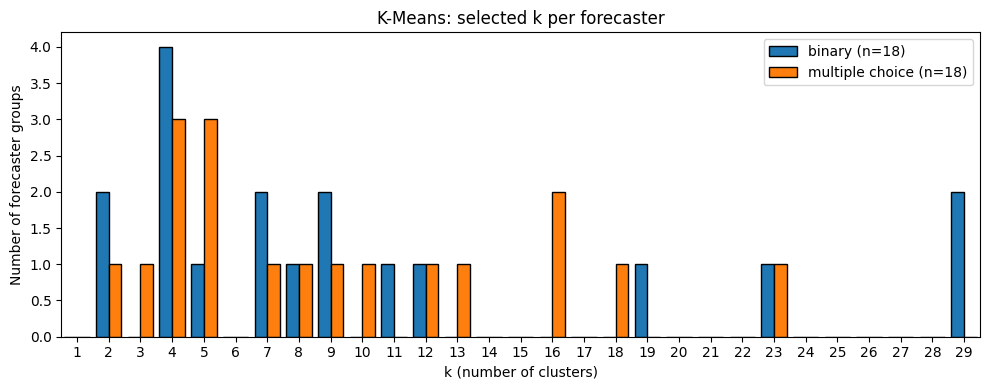

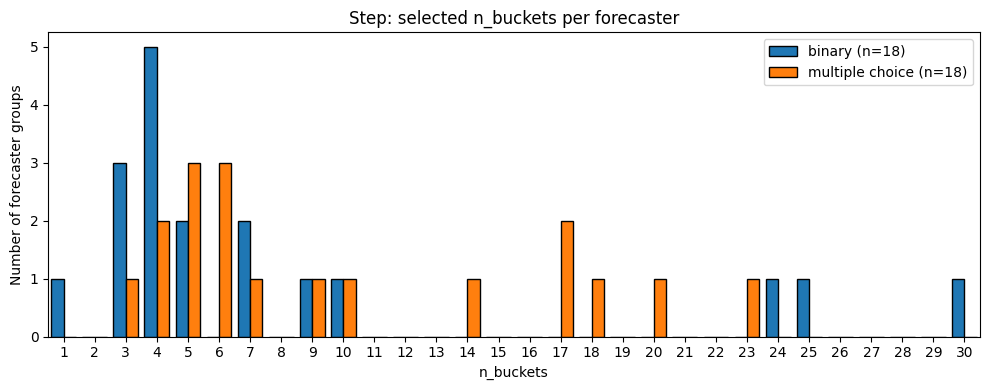

In [6]:
import matplotlib.pyplot as plt

counts_df = pd.DataFrame({
    "Question Type":   groups_with_adjustment["Split 2"].values,
    "K-Means k":       groups_with_adjustment["Adjuster K-Means Shift"].apply(lambda a: int(a.k)).values,
    "Step n_buckets":  groups_with_adjustment["Adjuster Step Shift"].apply(lambda a: int(a.n_buckets)).values,
})

def _grouped_bar(ax, counts_df, value_col, title, xlabel):
    x_max = max(int(counts_df[value_col].max()), 5)
    x_vals = np.arange(1, x_max + 1)
    width = 0.4
    offsets = {"binary": -width / 2, "multiple choice": +width / 2}
    colors  = {"binary": "tab:blue", "multiple choice": "tab:orange"}

    for qtype in ["binary", "multiple choice"]:
        sub = counts_df.loc[counts_df["Question Type"] == qtype, value_col]
        freq = sub.value_counts().reindex(x_vals, fill_value=0).sort_index()
        ax.bar(x_vals + offsets[qtype], freq.values, width=width,
               color=colors[qtype], edgecolor="black",
               label=f"{qtype} (n={len(sub)})")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of forecaster groups")
    ax.set_xticks(x_vals)
    ax.set_xlim(0.5, x_max + 0.5)
    ax.legend()

fig1, ax1 = plt.subplots(figsize=(10, 4))
_grouped_bar(ax1, counts_df, "K-Means k",
             "K-Means: selected k per forecaster",
             "k (number of clusters)")
fig1.tight_layout(); plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 4))
_grouped_bar(ax2, counts_df, "Step n_buckets",
             "Step: selected n_buckets per forecaster",
             "n_buckets")
fig2.tight_layout(); plt.show()

In [7]:
import json as _json

def _apply_adjuster(test_df: pd.DataFrame, adjuster) -> pd.DataFrame | None:
    if adjuster is None:
        return None
    adjusted = test_df.copy()
    for idx, row in adjusted.iterrows():
        if row["type"] == "binary":
            p = row.get("probability_yes")
            if p is not None and not (isinstance(p, float) and np.isnan(p)):
                try:
                    adjusted.at[idx, "probability_yes"] = adjuster.adjust_binary_forecast(float(p))
                except (ValueError, TypeError):
                    pass
        elif row["type"] == "multiple_choice":
            raw_probs = row.get("probability_yes_per_category")
            if raw_probs is not None and not (isinstance(raw_probs, float) and np.isnan(raw_probs)):
                try:
                    probs = _json.loads(raw_probs) if isinstance(raw_probs, str) else raw_probs
                    adj_probs = adjuster.adjust_multiple_choice_forecast(probs)
                    adjusted.at[idx, "probability_yes_per_category"] = _json.dumps(adj_probs) if isinstance(raw_probs, str) else adj_probs
                except (ValueError, TypeError, _json.JSONDecodeError):
                    pass
    return adjusted

groups_with_adjusted = groups_with_adjustment.copy()

for col_adj, col_out in [
    ("Adjuster Uniform Shift", "Adjusted Uniform Shift"),
    ("Adjuster Step Shift", "Adjusted Step Shift"),
    ("Adjuster K-Means Shift", "Adjusted K-Means Shift"),
    ("Adjuster Decision Tree", "Adjusted Decision Tree"),
    ("Adjuster Logistic Recalibration", "Adjusted Logistic Recalibration"),
]:
    groups_with_adjusted[col_out] = groups_with_adjusted.apply(
        lambda row, ca=col_adj: _apply_adjuster(row["Test"], row[ca]), axis=1
    )

groups_with_adjusted["Brier Raw"] = groups_with_adjusted["Test"].apply(_df_brier)

for col_out, brier_col in [
    ("Adjusted Uniform Shift", "Brier Adjusted Uniform Shift"),
    ("Adjusted Step Shift", "Brier Adjusted Step Shift"),
    ("Adjusted K-Means Shift", "Brier Adjusted K-Means Shift"),
    ("Adjusted Decision Tree", "Brier Adjusted Decision Tree"),
    ("Adjusted Logistic Recalibration", "Brier Adjusted Logistic Recalibration"),
]:
    groups_with_adjusted[brier_col] = groups_with_adjusted[col_out].apply(_df_brier)

# print("Adjustments made")

## Results

The following table shows the mean and median Brier scores for both the raw and adjusted forecasts, along with the $p$-value from a one-sided Wilcoxon signed-rank test under the alternative hypothesis that the raw Brier score exceeds the adjusted Brier score.

In [8]:
from scipy import stats

# Per-adjuster summary
adjuster_cols = [
    ("Uniform Shift", "Brier Adjusted Uniform Shift"),
    ("Step Shift", "Brier Adjusted Step Shift"),
    ("K-Means Shift", "Brier Adjusted K-Means Shift"),
    ("Decision Tree", "Brier Adjusted Decision Tree"),
    ("Logistic Recalibration", "Brier Adjusted Logistic Recalibration"),
]

summary_rows = []
for adj_name, brier_col in adjuster_cols:
    pre_valid = groups_with_adjusted[
        groups_with_adjusted[brier_col].notna()
        & groups_with_adjusted["Brier Raw"].notna()
    ]
    for question_type in ["binary", "multiple choice"]:
        valid = pre_valid[pre_valid["Split 2"] == question_type]
    
        summary_rows.append({
            "Adjuster": adj_name,
            "Question Type": question_type,
            
            "Mean Brier Raw": valid["Brier Raw"].mean(),
            "Mean Brier Adjusted": valid[brier_col].mean(),
            "Mean Delta": valid["Brier Raw"].mean() - valid[brier_col].mean(),
            "P Value": stats.wilcoxon(valid["Brier Raw"], valid[brier_col], alternative="greater").pvalue,
    
            "Median Brier Raw": valid["Brier Raw"].median(),
            "Median Brier Adjusted": valid[brier_col].median(),
            "Median Delta": valid["Brier Raw"].median() - valid[brier_col].median(),
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Adjuster,Question Type,Mean Brier Raw,Mean Brier Adjusted,Mean Delta,P Value,Median Brier Raw,Median Brier Adjusted,Median Delta
0,Uniform Shift,binary,0.18395,0.173510,0.010440,0.001682,0.188625,0.170535,0.018091
1,Uniform Shift,multiple choice,0.16770,0.169538,-0.001838,0.999853,0.165218,0.165751,-0.000533
2,Step Shift,binary,0.18395,0.173119,0.010831,0.024139,0.188625,0.173662,0.014963
3,Step Shift,multiple choice,0.16770,0.163287,0.004413,0.006016,0.165218,0.160578,0.004639
4,K-Means Shift,binary,0.18395,0.176302,0.007648,0.077023,0.188625,0.174047,0.014578
5,K-Means Shift,multiple choice,0.16770,0.162623,0.005078,0.000267,0.165218,0.160044,0.005173
6,Decision Tree,binary,0.18395,0.177222,0.006728,0.123104,0.188625,0.173135,0.015490
7,Decision Tree,multiple choice,0.16770,0.167296,0.000404,0.366863,0.165218,0.164870,0.000348
8,Logistic Recalibration,binary,0.18395,0.167524,0.016426,0.000523,0.188625,0.166202,0.022423
9,Logistic Recalibration,multiple choice,0.16770,0.162343,0.005357,0.000053,0.165218,0.159634,0.005583


The following tables ranks the strategies by $p$-value for binary and multiple choice questions respectively.

In [9]:
rank_df_binary = summary_df[summary_df["Question Type"] == "binary"][["Adjuster", "P Value", "Mean Delta", "Median Delta"]].sort_values(by = "P Value")

rank_df_mc = summary_df[summary_df["Question Type"] == "multiple choice"][["Adjuster", "P Value", "Mean Delta", "Median Delta"]].sort_values(by = "P Value")

from IPython.display import display_html
from itertools import chain,cycle
def display_side_by_side(*args,titles=cycle([''])):
    html_str='<div style="display:flex;gap:2rem;align-items:flex-start">'
    for df,title in zip(args, chain(titles,cycle(['</br>'])) ):
        html_str+='<div style="flex:1 1 0%;min-width:0">'
        html_str+=f'<h3 style="text-align: center;">{title}</h3>'
        html_str+=df.to_html().replace('<table ','<table style="display:inline" ')
        html_str+='</div>'
    html_str+='</div>'
    display_html(html_str,raw=True)

display_side_by_side(rank_df_binary, rank_df_mc, titles=["Binary Ranking", "Multiple Choice Ranking"])

,Adjuster,P Value,Mean Delta,Median Delta
8,Logistic Recalibration,0.000523,0.016426,0.022423
0,Uniform Shift,0.001682,0.010440,0.018091
2,Step Shift,0.024139,0.010831,0.014963
4,K-Means Shift,0.077023,0.007648,0.014578
6,Decision Tree,0.123104,0.006728,0.015490
,Adjuster,P Value,Mean Delta,Median Delta
9,Logistic Recalibration,0.000053,0.005357,0.005583
5,K-Means Shift,0.000267,0.005078,0.005173
3,Step Shift,0.006016,0.004413,0.004639
7,Decision Tree,0.366863,0.000404,0.000348


### Brier Score Distributions

The histograms below show the per-forecaster Brier score distribution before (gray) and after adjustment (colored) for each strategy. A leftward shift of the colored histogram relative to the gray histogram indicates improvement (lower Brier score). Rows correspond to question type (binary, multiple choice) and columns to each adjustment strategy.

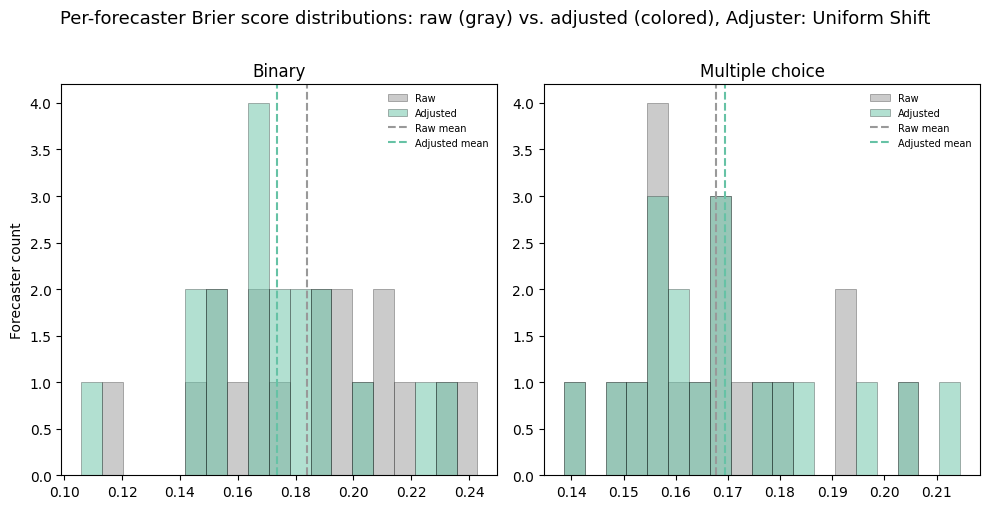

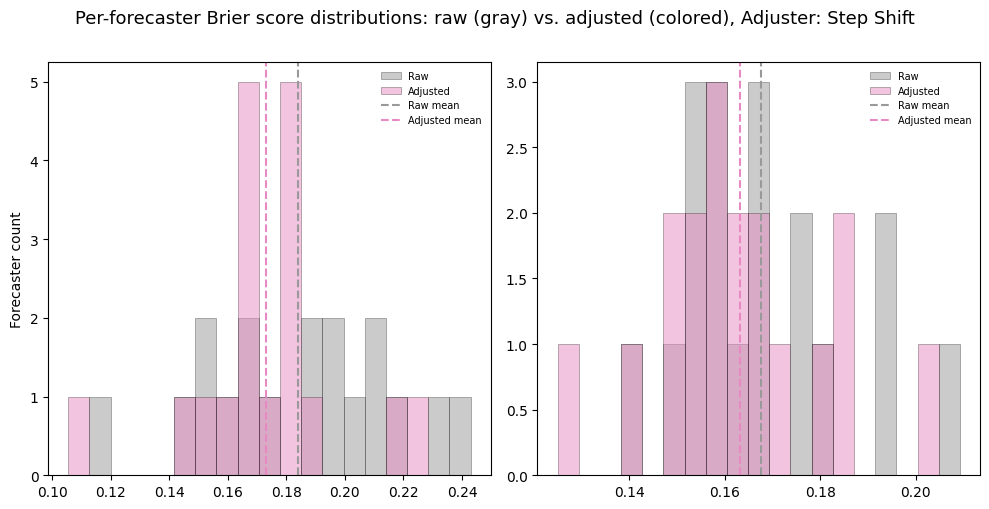

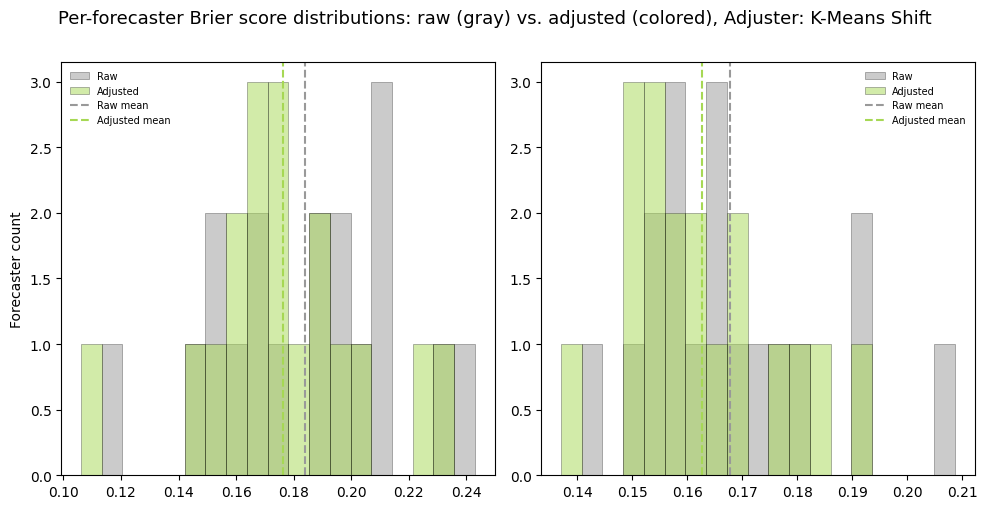

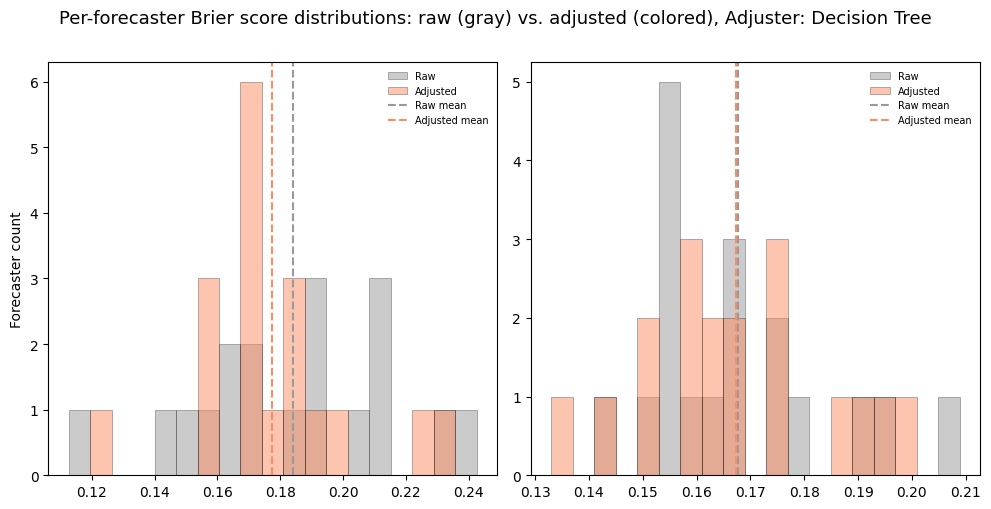

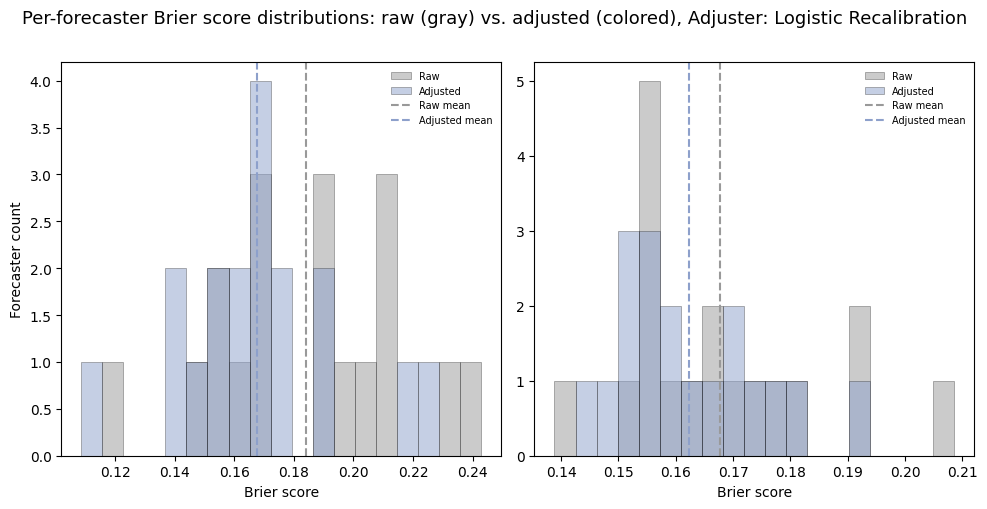

In [10]:
adj_plot_info = [
    ("Brier Adjusted Uniform Shift", "Uniform Shift", "#66c2a5"),
    ("Brier Adjusted Step Shift", "Step Shift", "#e78ac3"),
    ("Brier Adjusted K-Means Shift", "K-Means Shift", "#a6d854"),
    ("Brier Adjusted Decision Tree", "Decision Tree", "#fc8d62"),
    ("Brier Adjusted Logistic Recalibration", "Logistic Recalibration", "#8da0cb"),
]

q_types = ["binary", "multiple choice"]


for row_idx, (brier_col, adj_label, adj_color) in enumerate(adj_plot_info):
    fig, axes = plt.subplots(1, len(q_types), figsize=(10, 5), sharey="col")

    for col_idx, q_type in enumerate(q_types):
        ax = axes[col_idx]
        subset = groups_with_adjusted[groups_with_adjusted["Split 2"] == q_type]
        adj_scores = subset[["Brier Raw", brier_col]].dropna()[brier_col].values
        raw_matched = subset[["Brier Raw", brier_col]].dropna()["Brier Raw"].values

        all_vals = np.concatenate([raw_matched, adj_scores])
        lo, hi = all_vals.min(), all_vals.max()
        margin = (hi - lo) * 0.05 if hi > lo else 0.01
        bins = np.linspace(lo - margin, hi + margin, 20)

        ax.hist(raw_matched, bins=bins, alpha=0.5, color="#999999", label="Raw", edgecolor="black", linewidth=0.4)
        ax.hist(adj_scores, bins=bins, alpha=0.5, color=adj_color, label="Adjusted", edgecolor="black", linewidth=0.4)
        ax.axvline(raw_matched.mean(), color="#999999", linestyle="--", linewidth=1.5, label="Raw mean")
        ax.axvline(adj_scores.mean(), color=adj_color, linestyle="--", linewidth=1.5, label="Adjusted mean")

        if row_idx == 0:
            ax.set_title(q_type.capitalize())
        if col_idx == 0:
            ax.set_ylabel("Forecaster count")
        if row_idx == len(adj_plot_info) - 1:
            ax.set_xlabel("Brier score")
        ax.legend(fontsize=7, frameon=False)

    fig.suptitle(f"Per-forecaster Brier score distributions: raw (gray) vs. adjusted (colored), Adjuster: {adj_label}", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()

The following chart is a simple plot that compares the improvement in Brier score against the original Brier score pre-adjustment. The hypothesis that this checks is that, in general, the higher the input brier score, the less a model will improve it. A positive slope would agree with that hypothesis.

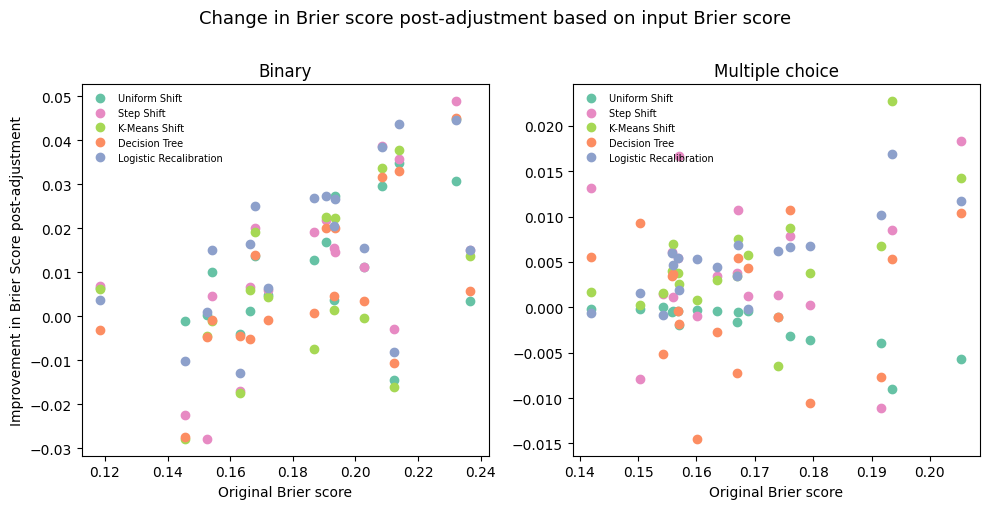

In [11]:
adj_plot_info = [
    ("Brier Adjusted Uniform Shift", "Uniform Shift", "#66c2a5"),
    ("Brier Adjusted Step Shift", "Step Shift", "#e78ac3"),
    ("Brier Adjusted K-Means Shift", "K-Means Shift", "#a6d854"),
    ("Brier Adjusted Decision Tree", "Decision Tree", "#fc8d62"),
    ("Brier Adjusted Logistic Recalibration", "Logistic Recalibration", "#8da0cb"),
]

q_types = ["binary", "multiple choice"]

fig, axes = plt.subplots(1, len(q_types), figsize=(10, 5), sharey="col")

for row_idx, (brier_col, adj_label, adj_color) in enumerate(adj_plot_info):
    for col_idx, q_type in enumerate(q_types):
        ax = axes[ col_idx]
        subset = groups_with_adjusted[groups_with_adjusted["Split 2"] == q_type]
        rows = subset[["Brier Raw", brier_col]].dropna()
        diffs = rows.apply(lambda row: row["Brier Raw"] - row[brier_col], axis=1)

        ax.plot(rows["Brier Raw"], diffs, 'o', color=adj_color, label=adj_label)

        if row_idx == 0:
            ax.set_title(q_type.capitalize())
        if col_idx == 0:
            ax.set_ylabel("Improvement in Brier Score post-adjustment")
        if row_idx == len(adj_plot_info) - 1:
            ax.set_xlabel("Original Brier score")
        ax.legend(fontsize=7, frameon=False)

fig.suptitle("Change in Brier score post-adjustment based on input Brier score", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

At least judging from the binary, it seems that the densest cluster of points is along a positive slope, which hints that the improvement by applying an adjuster may not be as strong, or may even be negative.

### Calibration Curves

The chart below visualizes calibration before and after adjustment. In a calibration curve, the x-axis is the predicted probability and the y-axis is the empirical resolution rate for predictions in that bin. A perfectly calibrated forecaster lies on the diagonal $y = x$: of all forecasts assigned probability 70%, the forecasted event should resolve positively 70% of the time.

Each panel compares the raw (gray) calibration curve against one adjuster (colored). The closer the colored curve lies to the diagonal relative to the gray curve, the more the adjuster improved calibration.

The calibration curves are aggregated across all forecasters. Each bin's plotted resolution rate is the fraction of outcomes that resolved positively among all forecasts falling within that probability range, aggregated across all forecasters, for either the raw or adjusted predictions.

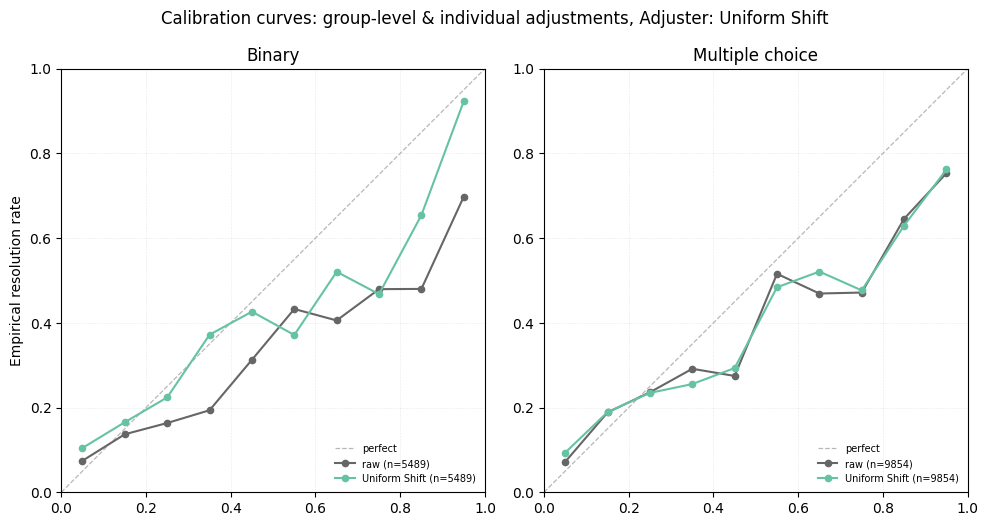

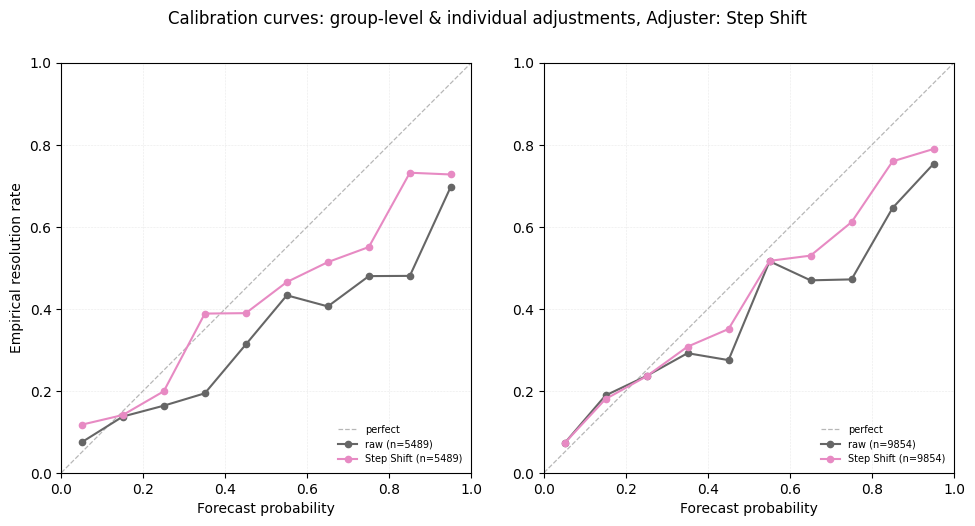

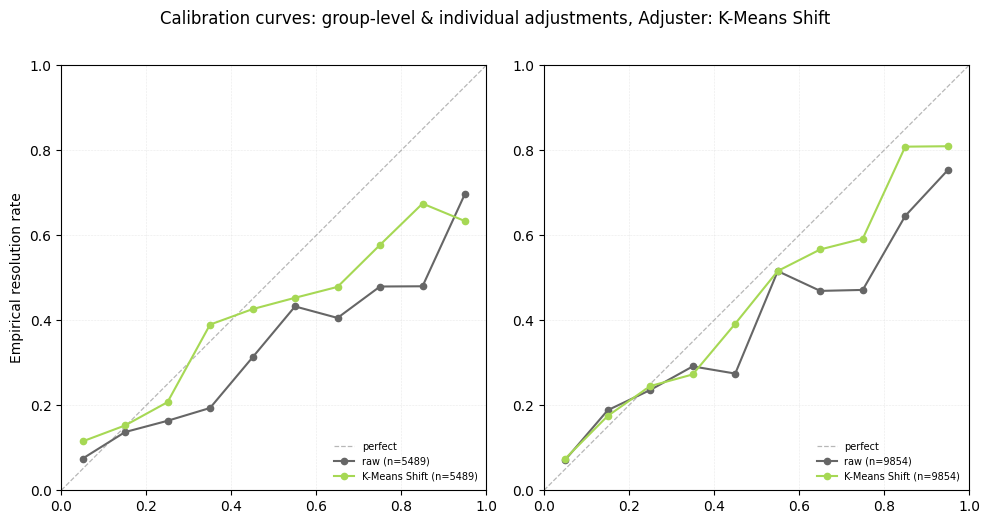

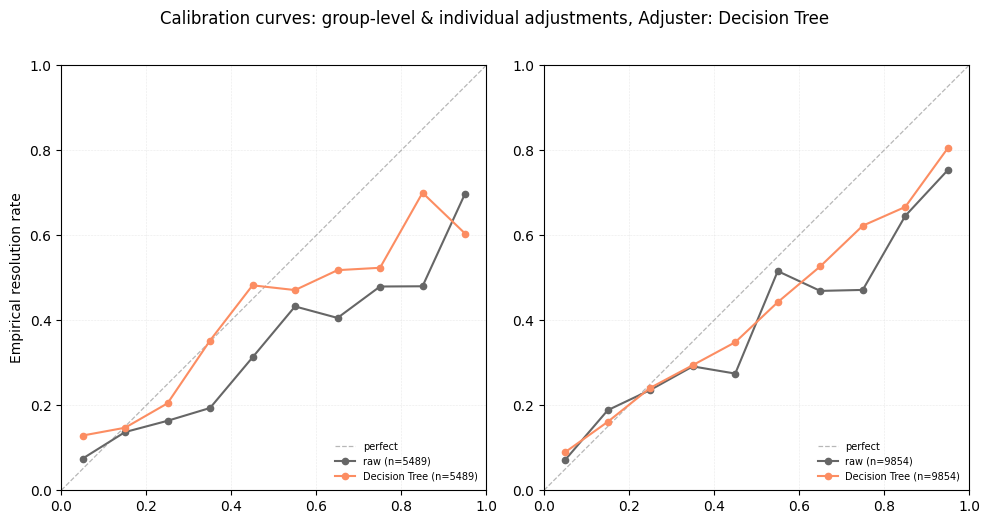

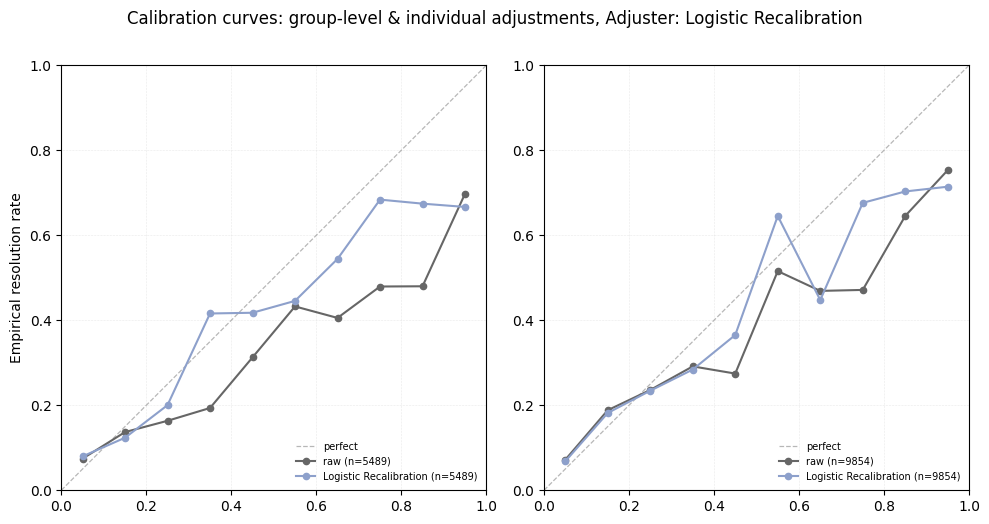

In [13]:
# Calibration curves: group-level and individual-level, binary and MC combined
def _calibration_points(probs, outcomes, n_bins=10):
    probs = np.asarray(probs, dtype=float)
    outcomes = np.asarray(outcomes, dtype=float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    midpoints, rates, counts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (probs >= lo) & (probs <= hi) if hi == 1.0 else (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        midpoints.append((lo + hi) / 2.0)
        rates.append(float(outcomes[mask].mean()))
        counts.append(int(mask.sum()))
    return np.array(midpoints), np.array(rates), np.array(counts)


def _extract_binary_probs_and_outcomes(df):
    """Extract (probs, outcomes) arrays from a binary-only test DataFrame."""
    if df is None or (isinstance(df, float) and np.isnan(df)):
        return np.array([]), np.array([])
    binary = df[(df["type"] == "binary") & df["resolution"].isin(["yes", "no"])]
    binary = binary[binary["probability_yes"].notna()]
    if binary.empty:
        return np.array([]), np.array([])
    probs = binary["probability_yes"].astype(float).values
    outcomes = (binary["resolution"] == "yes").astype(float).values
    return probs, outcomes


def _extract_mc_probs_and_outcomes(df):
    """Extract (probs, outcomes) arrays from MC rows in a test DataFrame."""
    if df is None or (isinstance(df, float) and np.isnan(df)):
        return np.array([]), np.array([])
    mc = df[df["type"] == "multiple_choice"].copy()
    if mc.empty:
        return np.array([]), np.array([])
    probs_list, outcomes_list = [], []
    for _, row in mc.iterrows():
        raw_probs = row.get("probability_yes_per_category")
        raw_options = row.get("options")
        res = row.get("resolution")
        if pd.isna(raw_probs) or pd.isna(raw_options) or pd.isna(res):
            continue
        try:
            p_vec = json.loads(raw_probs) if isinstance(raw_probs, str) else raw_probs
            options = json.loads(raw_options) if isinstance(raw_options, str) else raw_options
        except (TypeError, json.JSONDecodeError):
            continue
        if not isinstance(p_vec, list) or not isinstance(options, list):
            continue
        if len(p_vec) != len(options) or not options:
            continue
        if res not in options:
            continue
        for opt, p in zip(options, p_vec):
            try:
                p = float(p)
            except (ValueError, TypeError):
                continue
            if not 0.0 <= p <= 1.0:
                continue
            probs_list.append(p)
            outcomes_list.append(1.0 if opt == res else 0.0)
    if not probs_list:
        return np.array([]), np.array([])
    return np.array(probs_list), np.array(outcomes_list)


def _concat_from_individuals(rows, col, extractor):
    """Concatenate probs/outcomes from multiple individual forecaster rows using the given extractor."""
    all_probs, all_outcomes = [], []
    for _, r in rows.iterrows():
        p, o = extractor(r[col])
        if len(p):
            all_probs.append(p)
            all_outcomes.append(o)
    if not all_probs:
        return np.array([]), np.array([])
    return np.concatenate(all_probs), np.concatenate(all_outcomes)


adj_info = [
    ("Adjusted Uniform Shift", "Uniform Shift", "#66c2a5"),
    ("Adjusted Step Shift", "Step Shift", "#e78ac3"),
    ("Adjusted K-Means Shift", "K-Means Shift", "#a6d854"),
    ("Adjusted Decision Tree", "Decision Tree", "#fc8d62"),
    ("Adjusted Logistic Recalibration", "Logistic Recalibration", "#8da0cb"),
]

# Individual forecaster rows for binary and MC
individual_binary_rows = groups_with_adjusted[
   groups_with_adjusted["Split 2"] == "binary"
]
individual_mc_rows = groups_with_adjusted[
    groups_with_adjusted["Split 2"] == "multiple choice"
]

# 4 rows: binary group, binary individual, MC group, MC individual
# (row_label, mode, split2_value, extractor)
calib_rows = [
    (individual_binary_rows, "binary", _extract_binary_probs_and_outcomes),
    (individual_mc_rows, "multiple choice", _extract_mc_probs_and_outcomes),
]

for row_idx, (adj_col, adj_label, adj_color) in enumerate(adj_info):
    fig, axes = plt.subplots(1, len(q_types), figsize=(10, 5), sharey="col")
    for col_idx, (indiv, split2_val, extractor) in enumerate(calib_rows):
        raw_probs, raw_outcomes = _concat_from_individuals(indiv, "Test", extractor)
        
        ax = axes[col_idx]

        ax.plot([0, 1], [0, 1], "--", color="#999", linewidth=0.9, alpha=0.7, label="perfect")

        if len(raw_probs):
            mids, rates, _ = _calibration_points(raw_probs, raw_outcomes)
            ax.plot(mids, rates, "o-", color="#666", linewidth=1.5, markersize=4.5,
                    label=f"raw (n={len(raw_probs)})")

        adj_probs, adj_outcomes = _concat_from_individuals(indiv, adj_col, extractor)

        if len(adj_probs):
            mids, rates, _ = _calibration_points(adj_probs, adj_outcomes)
            ax.plot(mids, rates, "o-", color=adj_color, linewidth=1.5, markersize=4.5,
                    label=f"{adj_label} (n={len(adj_probs)})")

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.grid(True, linestyle=":", linewidth=0.4, alpha=0.5)
        ax.legend(loc="lower right", fontsize=7, frameon=False)

        if row_idx == 0:
            ax.set_title(split2_val.capitalize())
        if row_idx == len(calib_rows) - 1:
            ax.set_xlabel("Forecast probability")
        if col_idx == 0:
            ax.set_ylabel("Empirical resolution rate")

    fig.suptitle(f"Calibration curves: group-level & individual adjustments, Adjuster: {adj_label}", y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()

When interpreting these graphs, it is important to compare points on the same vertical line rather than along the axis normal to the perfect calibration line, as may be visually intuitive. It is also important to note that these graphs represent the aggregate across multiple forecasters; individual forecasters' calibration curves will look different.

In general, the auto-calibration has improved the visual fit to the diagonal, which is consistent with the conclusions from the hypothesis tests. However, these graphs should be interpreted with care and with reference to the $p$-values reported above. Because they aggregate across multiple forecasters, there can be a degree of smoothing that makes performance appear better than it is at the individual level, as is the case with the decision tree, which shows a visually plausible curve despite failing to reach statistical significance.

## Conclusions

This article has demonstrated that simple statistical calibration adjustments can produce meaningful, statistically significant improvements to forecaster accuracy as measured by the Brier score. Across five strategies of increasing complexity, logistic recalibration (Platt scaling) emerged as the clear best performer, achieving highly significant improvement for both binary and multiple-choice questions. Crucially, this result held across both question types simultaneously, which none of the other strategies achieved as convincingly. The step shift also achieved significance across both types, which is noteworthy given its simplicity.

The remaining strategies present a more nuanced picture. The uniform shift achieved significant improvement for binary questions, consistent with the theoretical argument that a global mean correction is well-suited to scalar predictions. However, as anticipated, it actively harmed performance on multiple-choice questions, where adding a constant offset and renormalizing collapses the adjusted predictions toward uniformity. The K-means shift showed the inverse pattern - significant for multiple-choice but not binary - suggesting that its data-adaptive cluster placement is better suited to the higher-dimensional structure of multiple-choice probability vectors. The decision tree failed to reach significance in either setting, which is most likely attributable to overfitting: its bin-level resolution rate estimates are sufficiently noisy at the available sample sizes that they do not generalize reliably to held-out data.

The results support practical recommendation: using an automated adjustment strategy (such as logistic recalibration) for automated forecasting pipelines is sensible to do by default, especially for simpler, more poorly calibrated forecasting agents. All the strategies used here are computationally trivial to apply at prediction time, and logistic recalibration specifically achieves significant improvement across both multiple choice and binary question types. That being said, better performing forecasting agents may not benefit as much from an adjustment, and some may be negatively impacted. As bots get better, applying an adjustment may not always result in a better performing output, so it would be wise to test an adjuster on some historical forecasts for any given bot that wishes to apply an adjuster before integration. Nonetheless, the methods here are not exhaustive, which warrants further investigation into methods that may perform more favorably on better performing bots.

A natural direction for future work is extending these calibration adjustment strategies to continuous distribution questions. Metaculus represents such forecasts as probability distributions over a bounded range. Miscalibration in this setting takes a different form than in the binary case: a forecaster's distributions may be systematically too narrow (overconfidence), shifted in one direction (bias), or asymmetrically skewed. The standard diagnostic tool is the **probability integral transform (PIT)**, which evaluates the forecaster's cumulative distribution function at each true outcome.

There are a couple strategies as candidates for recalibrating continuous questions. A location-scale recalibration (fitting a linear correction to the forecaster's median and a multiplicative correction to their distribution's width) is the direct generalization of Platt scaling and would be the natural first approach. Isotonic regression applied to the empirical PIT distribution can learn a nonparametric monotone correction to the quantile function without assuming a particular distribution family, analogous to the step shift or decision tree strategies explored here.